<a href="https://colab.research.google.com/github/Ariqueeezz/Enterprise-Brand-Sentiment-and-Campaign-Analytics-Pipeline/blob/epic%2FEBSCAP-1/EBSCAP_1_EBSCAP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EBSCAP-3: Download dan standardisasi dataset skala besar**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
output_dir = '/content/drive/MyDrive/EBSCAP/data/raw'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [2]:
import requests
from tqdm import tqdm

categories = "Amazon_Fashion"
base_url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories"

def download_file(url, dest_path):
    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get('content-length', 0))

    with open(dest_path, 'wb') as f, tqdm(
        desc=os.path.basename(dest_path),
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            size = f.write(chunk)
            bar.update(size)

    url = f"{base_url}/{categories}.jsonl.gz"
    dest = os.path.join(output_dir, f"{categories}.jsonl.gz")
    if os.path.exists(dest):
        print(f"Skip {categories}, sudah ada.")
    print(f"Downloading {categories}...")
    download_file(url, dest)

In [3]:
total_bytes = 0
path = os.path.join(output_dir, f"{categories}.jsonl.gz")
size = os.path.getsize(path)
total_bytes += size
print(f"{categories}: {size / (1024**3):.2f} GB")

print(f"\nTotal: {total_bytes / (1024**3):.2f} GB")

Amazon_Fashion: 0.27 GB

Total: 0.27 GB


In [4]:
import json
import gzip

sample_file = os.path.join(output_dir, f"{categories}.jsonl.gz")
with gzip.open(sample_file, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(json.loads(line))
        if i >= 2:
            break

{'rating': 5.0, 'title': 'Pretty locket', 'text': 'I think this locket is really pretty. The inside back is a solid silver depression and the front is a dome that is not solid (knotted). You could use it to store a small photo, lock of hair, etc but I use it when I need to carry medication with me. Closes securely. High quality & very pretty.', 'images': [], 'asin': 'B00LOPVX74', 'parent_asin': 'B00LOPVX74', 'user_id': 'AGBFYI2DDIKXC5Y4FARTYDTQBMFQ', 'timestamp': 1578528394489, 'helpful_vote': 3, 'verified_purchase': True}
{'rating': 5.0, 'title': 'A', 'text': 'Great', 'images': [], 'asin': 'B07B4JXK8D', 'parent_asin': 'B07B4JXK8D', 'user_id': 'AFQLNQNQYFWQZPJQZS6V3NZU4QBQ', 'timestamp': 1608426246701, 'helpful_vote': 0, 'verified_purchase': True}
{'rating': 2.0, 'title': 'Two Stars', 'text': 'One of the stones fell out within the first 2 weeks of wearing it. Stones smaller than expected.', 'images': [], 'asin': 'B007ZSEQ4Q', 'parent_asin': 'B007ZSEQ4Q', 'user_id': 'AHITBJSS7KYUBVZPX7M

# **EBSCAP-4: Setup local/cloud PySpark session dan sinkronisasi skema**

In [5]:
!pip install pyspark -q

In [6]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("BrandSentimentPipeline-EPIC1")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

In [8]:
raw_path = "/content/drive/MyDrive/EBSCAP/data/raw/Amazon_Fashion.jsonl.gz"

df_raw = spark.read.json(raw_path)
df_raw.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [9]:
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    BooleanType, LongType, ArrayType
)

review_schema = StructType([
    StructField("rating", DoubleType(), True),
    StructField("title", StringType(), True),
    StructField("text", StringType(), True),
    StructField("images", ArrayType(StringType()), True),
    StructField("asin", StringType(), True),
    StructField("parent_asin", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("timestamp", LongType(), True),
    StructField("verified_purchase", BooleanType(), True),
    StructField("helpful_vote", LongType(), True),
])

df = spark.read.schema(review_schema).json(raw_path)
df.printSchema()

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- helpful_vote: long (nullable = true)



In [10]:
df.show(5, truncate=50)

+------+--------------------+--------------------------------------------------+------+----------+-----------+----------------------------+-------------+-----------------+------------+
|rating|               title|                                              text|images|      asin|parent_asin|                     user_id|    timestamp|verified_purchase|helpful_vote|
+------+--------------------+--------------------------------------------------+------+----------+-----------+----------------------------+-------------+-----------------+------------+
|   5.0|       Pretty locket|I think this locket is really pretty. The insid...|    []|B00LOPVX74| B00LOPVX74|AGBFYI2DDIKXC5Y4FARTYDTQBMFQ|1578528394489|             true|           3|
|   5.0|                   A|                                             Great|    []|B07B4JXK8D| B07B4JXK8D|AFQLNQNQYFWQZPJQZS6V3NZU4QBQ|1608426246701|             true|           0|
|   2.0|           Two Stars|One of the stones fell out within the first 2 

In [11]:
print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")

Total rows: 2,500,939
Total columns: 10


In [12]:
df.cache()
df.count()

2500939

# **EBSCAP-5: Lakukan Exploratory Data Analysis (EDA) terdistribusi menggunakan Spark SQL**

## Distribusi Rating per-Review

In [13]:
df.createOrReplaceTempView("reviews")
rating_dist = spark.sql("""
    SELECT
        rating,
        COUNT(*) AS jumlah_review,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS persentase
    FROM reviews
    GROUP BY rating
    ORDER BY rating
""")
rating_dist.show()

+------+-------------+----------+
|rating|jumlah_review|persentase|
+------+-------------+----------+
|   1.0|       303411|     12.13|
|   2.0|       173462|      6.94|
|   3.0|       245471|      9.82|
|   4.0|       352327|     14.09|
|   5.0|      1426268|     57.03|
+------+-------------+----------+



## Mendeteksi Missing Values

In [14]:
from pyspark.sql.functions import col, sum as spark_sum, when

null_counts = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)

+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+
|rating|title|text|images|asin|parent_asin|user_id|timestamp|verified_purchase|helpful_vote|
+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+
|0     |0    |0   |0     |0   |0          |0      |0        |0                |0           |
+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+



## Ringkasan data 'text' atau ulasan pengguna keseluruhan review

In [15]:
from pyspark.sql.functions import length, split, size

df_with_wordcount = df.withColumn(
    "word_count", size(split(col("text"), " "))
)
df_with_wordcount.createOrReplaceTempView("reviews_wc")

word_stats = spark.sql("""
    SELECT
        MIN(word_count) AS min_kata,
        MAX(word_count) AS max_kata,
        ROUND(AVG(word_count), 1) AS rata_rata_kata,
        PERCENTILE_APPROX(word_count, 0.5) AS median_kata
    FROM reviews_wc
""")
word_stats.show()

+--------+--------+--------------+-----------+
|min_kata|max_kata|rata_rata_kata|median_kata|
+--------+--------+--------------+-----------+
|       1|    2225|          27.4|         17|
+--------+--------+--------------+-----------+



In [16]:
word_by_rating = spark.sql("""
    SELECT
        rating,
        ROUND(AVG(word_count), 1) AS rata_rata_kata,
        COUNT(*) AS jumlah_review
    FROM reviews_wc
    GROUP BY rating
    ORDER BY rating
""")
word_by_rating.show()

+------+--------------+-------------+
|rating|rata_rata_kata|jumlah_review|
+------+--------------+-------------+
|   1.0|          27.2|       303411|
|   2.0|          32.8|       173462|
|   3.0|          33.7|       245471|
|   4.0|          34.6|       352327|
|   5.0|          23.9|      1426268|
+------+--------------+-------------+



## Distribusi pengguna yang ter-verifikasi membeli produk yang di review

In [17]:
spark.sql("""
    SELECT verified_purchase, COUNT(*) AS jumlah
    FROM reviews
    GROUP BY verified_purchase
""").show()

+-----------------+-------+
|verified_purchase| jumlah|
+-----------------+-------+
|             true|2337702|
|            false| 163237|
+-----------------+-------+



## Visualisasi distribusi rating

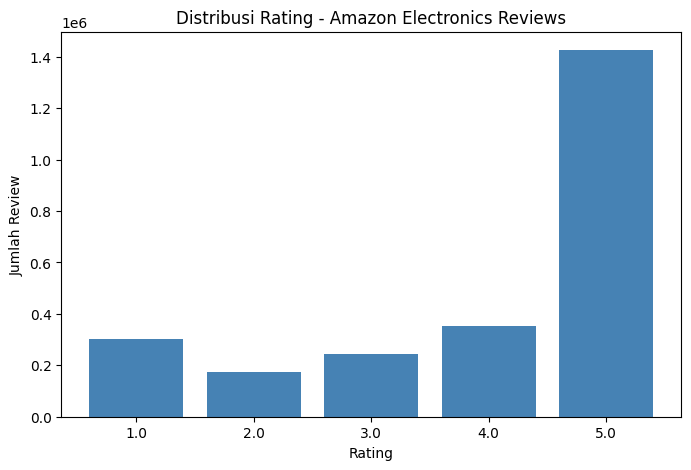

In [18]:
import matplotlib.pyplot as plt

rating_pd = rating_dist.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(rating_pd["rating"].astype(str), rating_pd["jumlah_review"], color="steelblue")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Rating - Amazon Fashion Reviews")
plt.show()

# **EBSCAP-7: Implementasi regex cleaner terdistribusi via PySpark UDF**

In [19]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.8 MB/s eta 0:00:00


In [20]:
from pyspark.sql.functions import regexp_replace, trim, lower, col

df_clean = df.withColumn(
    "text_clean",
    regexp_replace(col("text"), r"<[^>]+>", " ")  # remove HTML tags
)

df_clean = df_clean.withColumn(
    "text_clean",
    regexp_replace(col("text_clean"), r"http\S+|www\.\S+", " ")  # remove URL
)

df_clean = df_clean.withColumn(
    "text_clean",
    regexp_replace(col("text_clean"), r"[^a-zA-Z0-9\s.,!?']", " ")  # remove special chars (keep basic punctuation)
)

df_clean = df_clean.withColumn(
    "text_clean",
    trim(regexp_replace(col("text_clean"), r"\s+", " "))  # normalize whitespace
)

In [21]:
import emoji
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def remove_emoji(text):
    if text is None:
        return text
    return emoji.replace_emoji(text, replace=' ')

remove_emoji_udf = udf(remove_emoji, StringType())

df_clean = df_clean.withColumn(
    "text_clean",
    remove_emoji_udf(col("text_clean"))
)

In [22]:
df_clean = df_clean.withColumn("text_clean", lower(col("text_clean")))

# Filter baris yang jadi kosong/terlalu pendek setelah cleaning (data quality)
from pyspark.sql.functions import length

df_clean = df_clean.filter(length(trim(col("text_clean"))) > 0)

In [23]:
df_clean.select("text", "text_clean").show(5, truncate=80)

# Bandingkan jumlah baris sebelum & sesudah filter kosong
print(f"Baris sebelum cleaning: {df.count():,}")
# print(f"Baris sesudah cleaning: {df_clean.count():,}")

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                      text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|I think this locket is really pretty. The inside back is a solid silver depre...|i think this locket is really pretty. the inside back is a solid silver depre...|
|                                                                           Great|                                                                           great|
|One of the stones fell out within the first 2 weeks of wearing it. Stones sma...|one of the stones fell out within the first 2 weeks of wearing it. stones sma...|
|Crappy socks. M

In [24]:
df_clean.cache()
df_clean.count()    # trigger cache

2495548

# **EBSCAP-8: Bangun pipeline tokenisasi dan text vectorization (Word2Vec) menggunakan PySpark ML**

In [25]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover

tokenizer = Tokenizer(inputCol="text_clean", outputCol="tokens_raw")
df_tokens = tokenizer.transform(df_clean)

df_tokens.select("text_clean", "tokens_raw").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                      text_clean|                                                                      tokens_raw|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|i think this locket is really pretty. the inside back is a solid silver depre...|[i, think, this, locket, is, really, pretty., the, inside, back, is, a, solid...|
|                                                                           great|                                                                         [great]|
|one of the stones fell out within the first 2 weeks of wearing it. stones sma...|[one, of, the, stones, fell, out, within, the, first, 2, weeks, of, wearing, ...|
+---------------

In [26]:
default_stopwords = StopWordsRemover.loadDefaultStopWords("english")
negation_words = {"not", "no", "nor", "never", "none", "neither",
                   "don't", "doesn't", "didn't", "won't", "wouldn't",
                   "can't", "cannot", "isn't", "aren't", "wasn't", "weren't"}

custom_stopwords = [w for w in default_stopwords if w not in negation_words]

remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens_clean",
    stopWords=custom_stopwords
)
df_tokens = remover.transform(df_tokens)

In [27]:
from pyspark.ml.feature import HashingTF, IDF

hashing_tf = HashingTF(inputCol="tokens_clean", outputCol="raw_features", numFeatures=20000)
df_tf = hashing_tf.transform(df_tokens)

idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

df_tfidf.select("tokens_clean", "tfidf_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                    tokens_clean|                                                                  tfidf_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[think, locket, really, pretty., inside, back, solid, silver, depression, fro...|(20000,[504,1786,3501,3506,4112,5118,5164,5305,6333,7184,8430,9066,9324,10222...|
|                                                                         [great]|                                              (20000,[750],[2.0784086353748052])|
|[one, stones, fell, within, first, 2, weeks, wearing, it., stones, smaller, e...|(20000,[1154,1349,6403,6508,7945,9817,10815,14892,16320,17194,17805],[11.8785...|
+---------------

In [28]:
from pyspark.ml.feature import Word2Vec

word2vec = Word2Vec(
    vectorSize=100,        # dimensi embedding, umum dipakai 100-300
    minCount=5,            # abaikan kata yang muncul <5 kali (noise reduction)
    inputCol="tokens_clean",
    outputCol="w2v_features"
)

word2vec_model = word2vec.fit(df_tokens)
df_w2v = word2vec_model.transform(df_tokens)

df_w2v.select("tokens_clean", "w2v_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                    tokens_clean|                                                                    w2v_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[think, locket, really, pretty., inside, back, solid, silver, depression, fro...|[0.1101121269603027,0.1049625192390522,0.03133646282367408,-0.075119322542377...|
|                                                                         [great]|[-0.4335428476333618,0.09386194497346878,0.019593676552176476,-0.112238332629...|
|[one, stones, fell, within, first, 2, weeks, wearing, it., stones, smaller, e...|[0.14598384456864247,0.05264681251719594,0.02678435963268081,-0.0732996352016...|
+---------------

In [29]:
word2vec_model.findSynonyms("battery", 5).show()
word2vec_model.findSynonyms("broken", 5).show()

+----------+------------------+
|      word|        similarity|
+----------+------------------+
| batteries|0.8740619421005249|
|  battery,|0.8595554232597351|
|  battery.|0.8499627113342285|
|batteries.|0.8215572237968445|
|     dead.|0.7818387150764465|
+----------+------------------+

+-------+------------------+
|   word|        similarity|
+-------+------------------+
|broken.|0.9051990509033203|
|broken,|0.8946565985679626|
|broken!|0.8265900611877441|
|damaged|0.7776819467544556|
|missing|0.7720838189125061|
+-------+------------------+



In [30]:
output_base = "/content/drive/MyDrive/skripsi-project/data/processed"

word2vec_model.save(f"{output_base}/word2vec_model")
idf_model.save(f"{output_base}/idf_model")

df_w2v.select("rating", "text_clean", "tokens_clean", "w2v_features") \
    .write.mode("overwrite").parquet(f"{output_base}/reviews_w2v.parquet")